In [1]:
import sys
import os
import pandas as pd
# Add the parent directory (simcode) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from src.dgp import GaussianNetwork
from src.metrics import Rejection, FalseRejection, rv_coefficient
from src.methods import RVPermutationTest
from src.simulation_functions import run_simulation
from src.analyse_functions import aggregate_results
import re
from src.plot_functions import plot_grid, plot_with_bands
import ast

In [2]:
results = pd.read_csv("simulation_results_20260203_0905.csv") 

In [3]:
#setup
# nsim = 20
# n = [10, 25, 50, 100, 150]
# k = [2, 5, 7]
# sigma = [0, 0.01, 0.1, 0.5]
# alpha = [0.05]
# marginal_z = [stats.norm(loc=0, scale=1), stats.laplace(loc=0, scale=1)]
# edge_var = [1, 3, 5]
# dgp = [GaussianNetwork, BernoulliNetwork]
# methods = [RVPermutationTest, LLKRatioTest]
# metrics = [ComputeAll()]
# rv_coefficient_function = [rv_coefficient_adjusted]
# approximation = ['F-distr']
# npermutations = [1000]

In [4]:
results['method'] = results['args'].apply(lambda x: re.search(r"'method':.*?\.(\w+?)(?=Test)", x).group(1).lower())
results['sigma'] = results['args'].apply(lambda x: re.search(r"'sigma':\s*(\d+\.?\d*)", x).group(1))
results['ComputeAll'] = results['ComputeAll'].apply(lambda x: ast.literal_eval(re.sub(r"np\.float64\(([^)]+)\)", r"\1", x)))

In [5]:
results['MSE_x'] = results['ComputeAll'].apply(lambda x: x['MSE_x'])  
results['MSE_z'] = results['ComputeAll'].apply(lambda x: x['MSE_z'])  
results['RelativeFrobeniusNorm_x'] = results['ComputeAll'].apply(lambda x: x['RelativeFrobeniusNorm_x'])  
results['RelativeFrobeniusNorm_z'] = results['ComputeAll'].apply(lambda x: x['RelativeFrobeniusNorm_z'])  
results['FalseRejection'] = results['ComputeAll'].apply(lambda x: x['FalseRejection'])  
results['TrueRejection'] = results['ComputeAll'].apply(lambda x: x['TrueRejection'])  
results['Rejection'] = results['ComputeAll'].apply(lambda x: x['Rejection'])  

### Defining different aggregations

In [6]:
# based on dgp
results_gaussian = results[(results['dgp'] == 'GaussianNetwork')].copy()
results_bernoulli = results[(results['dgp'] == 'BernoulliNetwork')].copy()

In [7]:
# based on sigma + dgp
results_null_gaussian = results_gaussian[(results_gaussian['sigma'] == '0')].copy()
results_alt_05_gaussian = results_gaussian[(results_gaussian['sigma'] == '0.5')].copy()
results_alt_001_gaussian = results_gaussian[(results_gaussian['sigma'] == '0.01')].copy()
results_alt_01_gaussian = results_gaussian[(results_gaussian['sigma'] == '0.1')].copy()

results_null_bernoulli = results_bernoulli[(results_bernoulli['sigma'] == '0')].copy()
results_alt_05_bernoulli = results_bernoulli[(results_bernoulli['sigma'] == '0.5')].copy()
results_alt_001_bernoulli = results_bernoulli[(results_bernoulli['sigma'] == '0.01')].copy()
results_alt_01_bernoulli = results_bernoulli[(results_bernoulli['sigma'] == '0.1')].copy()

In [8]:
# based on sigma + dgp + marginals
results_null_gaussian_gaus_margins = results_null_gaussian[results_null_gaussian['marginal_z'].str.contains('norm', case=False, na=False)].copy()

results_alt_05_gaussian_gaus_margins = results_alt_05_gaussian[results_alt_05_gaussian['marginal_z'].str.contains('norm', case=False, na=False)].copy()

results_alt_001_gaussian_gaus_margins = results_alt_001_gaussian[results_alt_001_gaussian['marginal_z'].str.contains('norm', case=False, na=False)].copy()

results_alt_01_gaussian_gaus_margins = results_alt_01_gaussian[results_alt_01_gaussian['marginal_z'].str.contains('norm', case=False, na=False)].copy()

results_null_bernoulli_gaus_margins = results_null_bernoulli[results_null_bernoulli['marginal_z'].str.contains('norm', case=False, na=False)].copy()

results_alt_05_bernoulli_gaus_margins = results_alt_05_bernoulli[results_alt_05_bernoulli['marginal_z'].str.contains('norm', case=False, na=False)].copy()

results_alt_001_bernoulli_gaus_margins = results_alt_001_bernoulli[results_alt_001_bernoulli['marginal_z'].str.contains('norm', case=False, na=False)].copy()

results_alt_01_bernoulli_gaus_margins = results_alt_01_bernoulli[results_alt_01_bernoulli['marginal_z'].str.contains('norm', case=False, na=False)].copy()

results_null_gaussian_laplace_margins = results_null_gaussian[results_null_gaussian['marginal_z'].str.contains('laplace', case=False, na=False)].copy()

results_alt_05_gaussian_laplace_margins = results_alt_05_gaussian[results_alt_05_gaussian['marginal_z'].str.contains('laplace', case=False, na=False)].copy()

results_alt_001_gaussian_laplace_margins = results_alt_001_gaussian[results_alt_001_gaussian['marginal_z'].str.contains('laplace', case=False, na=False)].copy()

results_alt_01_gaussian_laplace_margins = results_alt_01_gaussian[results_alt_01_gaussian['marginal_z'].str.contains('laplace', case=False, na=False)].copy()

results_null_bernoulli_laplace_margins = results_null_bernoulli[results_null_bernoulli['marginal_z'].str.contains('laplace', case=False, na=False)].copy()

results_alt_05_bernoulli_laplace_margins = results_alt_05_bernoulli[results_alt_05_bernoulli['marginal_z'].str.contains('laplace', case=False, na=False)].copy()

results_alt_01_bernoulli_laplace_margins = results_alt_01_bernoulli[results_alt_01_bernoulli['marginal_z'].str.contains('laplace', case=False, na=False)].copy()

results_alt_001_bernoulli_laplace_margins = results_alt_001_bernoulli[results_alt_001_bernoulli['marginal_z'].str.contains('laplace', case=False, na=False)].copy()

In [9]:
# based on sigma + dgp + marginals + solver
results_null_gaussian_gaus_margins_gaus_mle = results_null_gaussian_gaus_margins[(results_null_gaussian_gaus_margins['solver'] == 'MLE_gaussian')].copy()
results_null_gaussian_laplace_margins_gaus_mle = results_null_gaussian_laplace_margins[(results_null_gaussian_laplace_margins['solver'] == 'MLE_gaussian')].copy()

results_null_bernoulli_gaus_margins_logistic_mle = results_null_bernoulli_gaus_margins[(results_null_bernoulli_gaus_margins['solver'] == 'MLE_logistic')].copy()
results_null_bernoulli_laplace_margins_logistic_mle = results_null_bernoulli_laplace_margins[(results_null_bernoulli_laplace_margins['solver'] == 'MLE_logistic')].copy()

results_alt_05_gaussian_gaus_margins_gaus_mle = results_alt_05_gaussian_gaus_margins[(results_alt_05_gaussian_gaus_margins['solver'] == 'MLE_gaussian')].copy()
results_alt_05_gaussian_laplace_margins_gaus_mle = results_alt_05_gaussian_laplace_margins[(results_alt_05_gaussian_laplace_margins['solver'] == 'MLE_gaussian')].copy()
results_alt_01_gaussian_gaus_margins_gaus_mle = results_alt_01_gaussian_gaus_margins[(results_alt_01_gaussian_gaus_margins['solver'] == 'MLE_gaussian')].copy()
results_alt_01_gaussian_laplace_margins_gaus_mle = results_alt_01_gaussian_laplace_margins[(results_alt_01_gaussian_laplace_margins['solver'] == 'MLE_gaussian')].copy()
results_alt_001_gaussian_gaus_margins_gaus_mle = results_alt_001_gaussian_gaus_margins[(results_alt_001_gaussian_gaus_margins['solver'] == 'MLE_gaussian')].copy()
results_alt_001_gaussian_laplace_margins_gaus_mle = results_alt_001_gaussian_laplace_margins[(results_alt_001_gaussian_laplace_margins['solver'] == 'MLE_gaussian')].copy()

results_alt_05_bernoulli_gaus_margins_logistic_mle = results_alt_05_bernoulli_gaus_margins[(results_alt_05_bernoulli_gaus_margins['solver'] == 'MLE_logistic')].copy()
results_alt_05_bernoulli_laplace_margins_logistic_mle = results_alt_05_bernoulli_laplace_margins[(results_alt_05_bernoulli_laplace_margins['solver'] == 'MLE_logistic')].copy()
results_alt_01_bernoulli_gaus_margins_logistic_mle = results_alt_01_bernoulli_gaus_margins[(results_alt_01_bernoulli_gaus_margins['solver'] == 'MLE_logistic')].copy()
results_alt_01_bernoulli_laplace_margins_logistic_mle = results_alt_01_bernoulli_laplace_margins[(results_alt_01_bernoulli_laplace_margins['solver'] == 'MLE_logistic')].copy()
results_alt_001_bernoulli_gaus_margins_logistic_mle = results_alt_001_bernoulli_gaus_margins[(results_alt_001_bernoulli_gaus_margins['solver'] == 'MLE_logistic')].copy()
results_alt_001_bernoulli_laplace_margins_logistic_mle = results_alt_001_bernoulli_laplace_margins[(results_alt_001_bernoulli_laplace_margins['solver'] == 'MLE_logistic')].copy()

In [10]:
#based on sigma + method + dgp
results_llk_ratio_null_gaussian = results_gaussian[(results_gaussian['method'] == 'llkratio') & (results_gaussian['sigma'] == '0')].copy()
results_llk_ratio_alt_001_gaussian = results_gaussian[(results_gaussian['method'] == 'llkratio') & (results_gaussian['sigma'] == '0.01')].copy()
results_llk_ratio_alt_05_gaussian = results_gaussian[(results_gaussian['method'] == 'llkratio') & (results_gaussian['sigma'] == '0.5')].copy()
results_llk_ratio_alt_01_gaussian = results_gaussian[(results_gaussian['method'] == 'llkratio') & (results_gaussian['sigma'] == '0.1')].copy()

results_rv_null_gaussian = results_gaussian[(results_gaussian['method'] == 'rvpermutation') & (results_gaussian['sigma'] == '0')].copy()
results_rv_alt_001_gaussian = results_gaussian[(results_gaussian['method'] == 'rvpermutation') & (results_gaussian['sigma'] == '0.01')].copy()
results_rv_alt_05_gaussian = results_gaussian[(results_gaussian['method'] == 'rvpermutation') & (results_gaussian['sigma'] == '0.5')].copy()
results_rv_alt_01_gaussian = results_gaussian[(results_gaussian['method'] == 'rvpermutation') & (results_gaussian['sigma'] == '0.1')].copy()

results_llk_ratio_null_bernoulli = results_bernoulli[(results_bernoulli['method'] == 'llkratio') & (results_bernoulli['sigma'] == '0')].copy()
results_llk_ratio_alt_001_bernoulli = results_bernoulli[(results_bernoulli['method'] == 'llkratio') & (results_bernoulli['sigma'] == '0.01')].copy()
results_llk_ratio_alt_05_bernoulli = results_bernoulli[(results_bernoulli['method'] == 'llkratio') & (results_bernoulli['sigma'] == '0.5')].copy()
results_llk_ratio_alt_01_bernoulli = results_bernoulli[(results_bernoulli['method'] == 'llkratio') & (results_bernoulli['sigma'] == '0.1')].copy()

results_rv_null_bernoulli = results_bernoulli[(results_bernoulli['method'] == 'rvpermutation') & (results_bernoulli['sigma'] == '0')].copy()
results_rv_alt_001_bernoulli = results_bernoulli[(results_bernoulli['method'] == 'rvpermutation') & (results_bernoulli['sigma'] == '0.01')].copy()
results_rv_alt_05_bernoulli = results_bernoulli[(results_bernoulli['method'] == 'rvpermutation') & (results_bernoulli['sigma'] == '0.5')].copy()
results_rv_alt_01_bernoulli = results_bernoulli[(results_bernoulli['method'] == 'rvpermutation') & (results_bernoulli['sigma'] == '0.1')].copy()

## Plots

**Ensure type I error is controlled at 5%**

In [11]:
# for the null extract the false rejection to study type I error
agg_null_gaussian_gaus_margins_gaus_mle = aggregate_results(results_null_gaussian_gaus_margins_gaus_mle, y_axis='FalseRejection', x_axis='n', factors=['edge_var', 'k', 'method'])
agg_null_gaussian_laplace_margins_gaus_mle = aggregate_results(results_null_gaussian_laplace_margins_gaus_mle, y_axis='FalseRejection', x_axis='n', factors=['edge_var', 'k', 'method'])
agg_null_bernoulli_gaus_margins_logistic_mle = aggregate_results(results_null_bernoulli_gaus_margins_logistic_mle, y_axis='FalseRejection', x_axis='n', factors=['edge_var', 'k', 'method'])
agg_null_bernoulli_laplace_margins_logistic_mle = aggregate_results(results_null_bernoulli_laplace_margins_logistic_mle, y_axis='FalseRejection', x_axis='n', factors=['edge_var', 'k', 'method'])

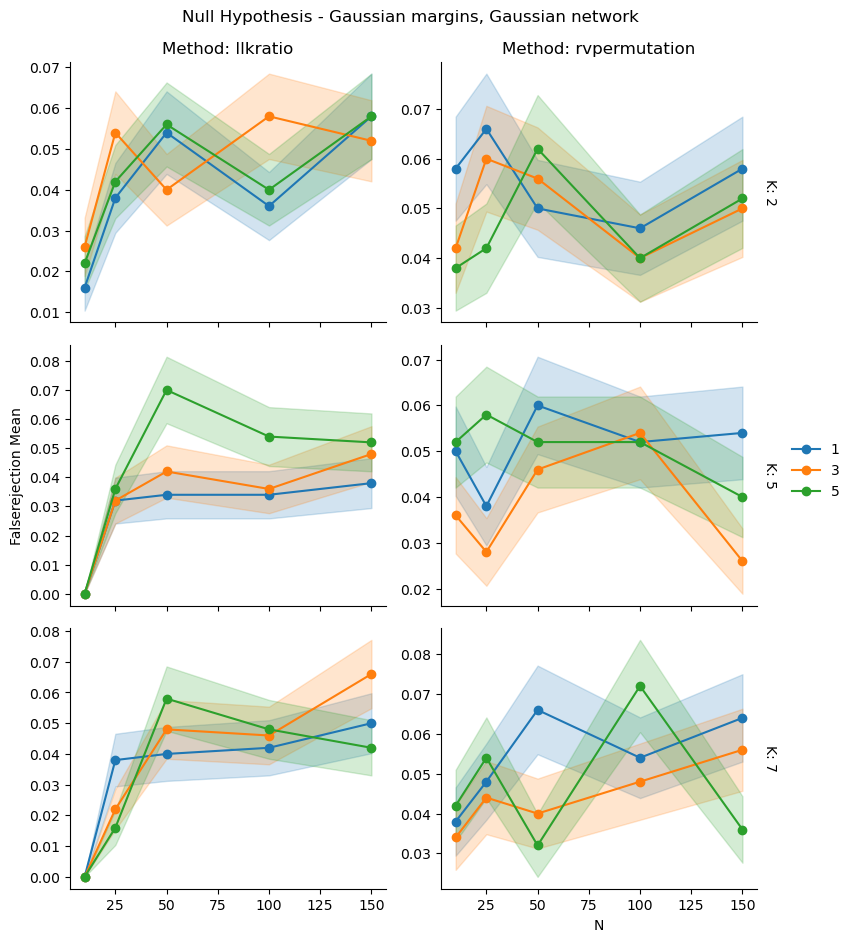

In [12]:
plot_grid(
        grouped_stats=agg_null_gaussian_gaus_margins_gaus_mle,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='FalseRejection_mean',
        factors=['edge_var', 'method', 'k'],
        height=3,
        se_bands='FalseRejection_sem',
        share_x=True,
        share_y=False,
        title='Null Hypothesis - Gaussian margins, Gaussian network ',
    )

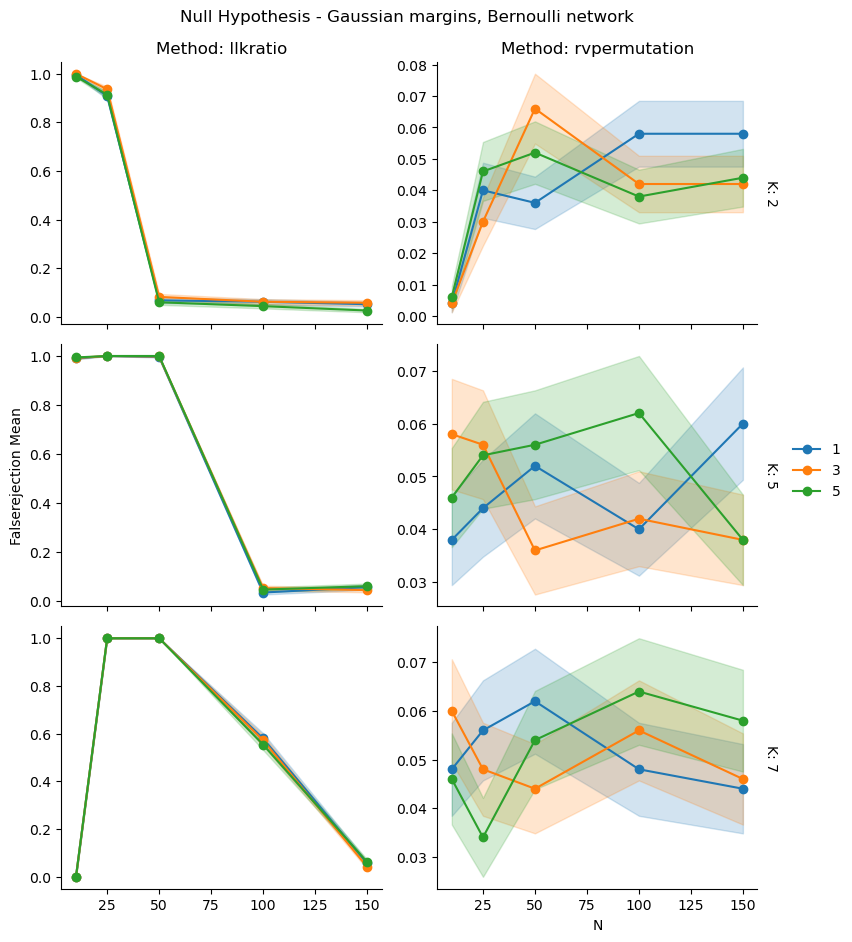

In [13]:
plot_grid(
        grouped_stats=agg_null_bernoulli_gaus_margins_logistic_mle,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='FalseRejection_mean',
        factors=['edge_var', 'method', 'k'],
        height=3,
        se_bands='FalseRejection_sem',
        share_x=True,
        share_y=False,
        title='Null Hypothesis - Gaussian margins, Bernoulli network ',
    )

In [14]:
# plot_grid(
#         grouped_stats=agg_null_gaussian_laplace_margins_gaus_mle,
#         plotting_function=plot_with_bands,
#         x_axis='n',
#         y_axis='FalseRejection_mean',
#         factors=['edge_var', 'method', 'k'],
#         height=3,
#         se_bands='FalseRejection_sem',
#         share_x=True,
#         share_y=False,
#         title='Null Hypothesis - Laplace margins, Gaussian network ',
#     )

In [15]:
# plot_grid(
#         grouped_stats=agg_null_bernoulli_laplace_margins_logistic_mle,
#         plotting_function=plot_with_bands,
#         x_axis='n',
#         y_axis='FalseRejection_mean',
#         factors=['edge_var', 'method', 'k'],
#         height=3,
#         se_bands='FalseRejection_sem',
#         share_x=True,
#         share_y=False,
#         title='Null Hypothesis - Laplace margins, Bernoulli network ',
#     )

# Study Power

In [16]:
# based on sigma + dgp + marginals + solver
agg_alt_001_gaussian_gaus_margins_gaus_mle = aggregate_results(results_alt_001_gaussian_gaus_margins_gaus_mle, y_axis='TrueRejection', x_axis='n', factors=['edge_var', 'k', 'method'])
agg_alt_001_gaussian_laplace_margins_gaus_mle = aggregate_results(results_alt_001_gaussian_laplace_margins_gaus_mle, y_axis='TrueRejection', x_axis='n', factors=['edge_var', 'k', 'method'])
agg_alt_001_bernoulli_gaus_margins_logistic_mle = aggregate_results(results_alt_001_bernoulli_gaus_margins_logistic_mle, y_axis='TrueRejection', x_axis='n', factors=['edge_var', 'k', 'method'])
agg_alt_001_bernoulli_laplace_margins_logistic_mle = aggregate_results(results_alt_001_bernoulli_laplace_margins_logistic_mle, y_axis='TrueRejection', x_axis='n', factors=['edge_var', 'k', 'method'])

agg_alt_01_gaussian_gaus_margins_gaus_mle = aggregate_results(results_alt_01_gaussian_gaus_margins_gaus_mle, y_axis='TrueRejection', x_axis='n', factors=['edge_var', 'k', 'method'])
agg_alt_01_gaussian_laplace_margins_gaus_mle = aggregate_results(results_alt_01_gaussian_laplace_margins_gaus_mle, y_axis='TrueRejection', x_axis='n', factors=['edge_var', 'k', 'method'])
agg_alt_01_bernoulli_gaus_margins_logistic_mle = aggregate_results(results_alt_01_bernoulli_gaus_margins_logistic_mle, y_axis='TrueRejection', x_axis='n', factors=['edge_var', 'k', 'method'])
agg_alt_01_bernoulli_laplace_margins_logistic_mle = aggregate_results(results_alt_01_bernoulli_laplace_margins_logistic_mle, y_axis='TrueRejection', x_axis='n', factors=['edge_var', 'k', 'method'])

agg_alt_05_gaussian_gaus_margins_gaus_mle = aggregate_results(results_alt_05_gaussian_gaus_margins_gaus_mle, y_axis='TrueRejection', x_axis='n', factors=['edge_var', 'k', 'method'])
agg_alt_05_gaussian_laplace_margins_gaus_mle = aggregate_results(results_alt_05_gaussian_laplace_margins_gaus_mle, y_axis='TrueRejection', x_axis='n', factors=['edge_var', 'k', 'method'])
agg_alt_05_bernoulli_gaus_margins_logistic_mle = aggregate_results(results_alt_05_bernoulli_gaus_margins_logistic_mle, y_axis='TrueRejection', x_axis='n', factors=['edge_var', 'k', 'method'])
agg_alt_05_bernoulli_laplace_margins_logistic_mle = aggregate_results(results_alt_05_bernoulli_laplace_margins_logistic_mle, y_axis='TrueRejection', x_axis='n', factors=['edge_var', 'k', 'method'])

## Alternative Gaus margins

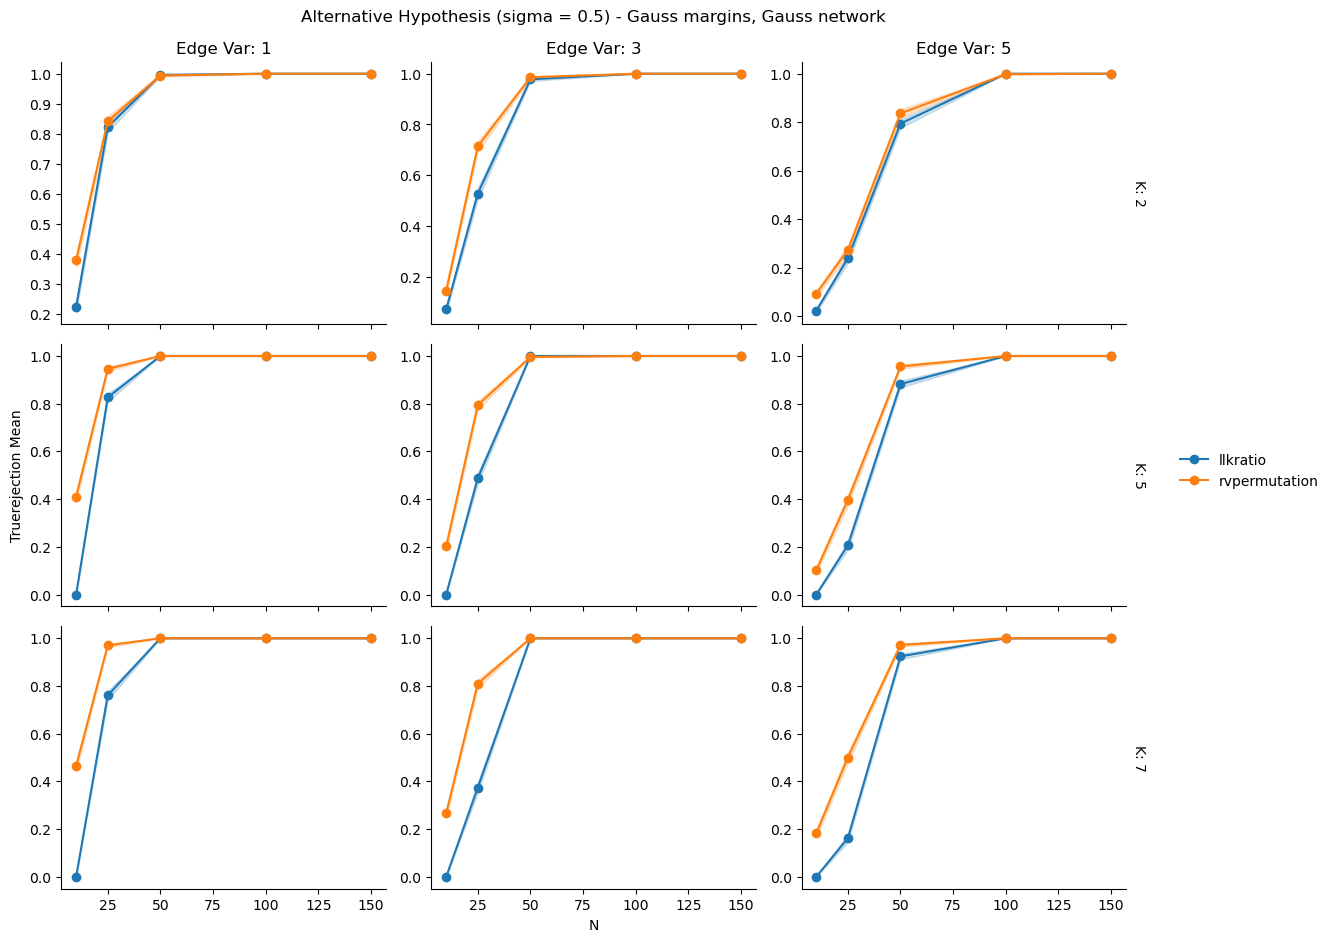

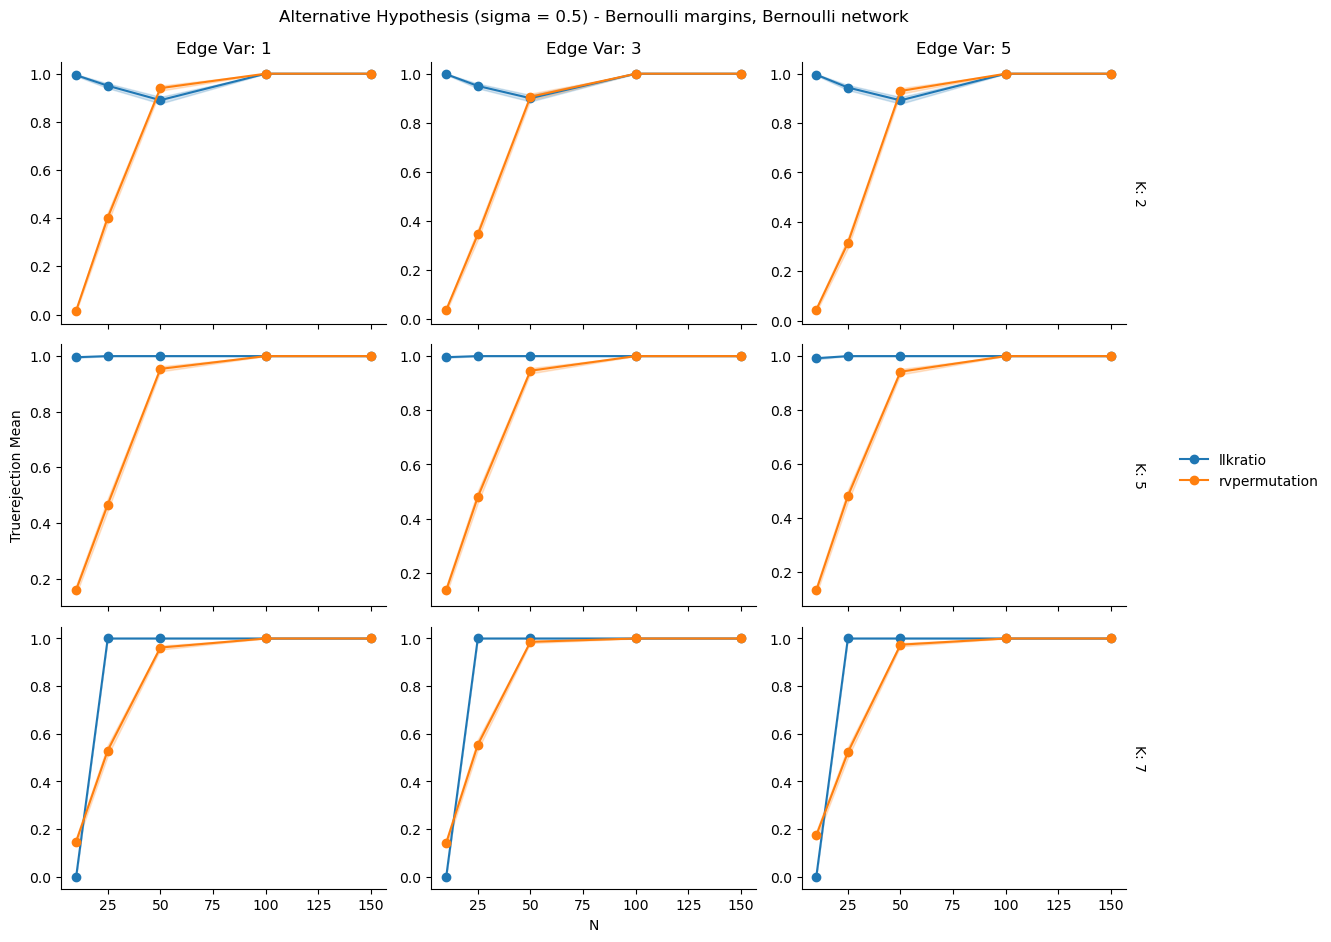

In [17]:
# sigma 0.5
plot_grid(
        grouped_stats=agg_alt_05_gaussian_gaus_margins_gaus_mle,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='TrueRejection_mean',
        factors=['method', 'edge_var', 'k'],
        height=3,
        se_bands='TrueRejection_sem',
        share_x=True,
        share_y=False,
        title='Alternative Hypothesis (sigma = 0.5) - Gauss margins, Gauss network'
    )

plot_grid(
        grouped_stats=agg_alt_05_bernoulli_gaus_margins_logistic_mle,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='TrueRejection_mean',
        factors=['method', 'edge_var', 'k'],
        height=3,
        se_bands='TrueRejection_sem',
        share_x=True,
        share_y=False,
        title='Alternative Hypothesis (sigma = 0.5) - Bernoulli margins, Bernoulli network'
    )

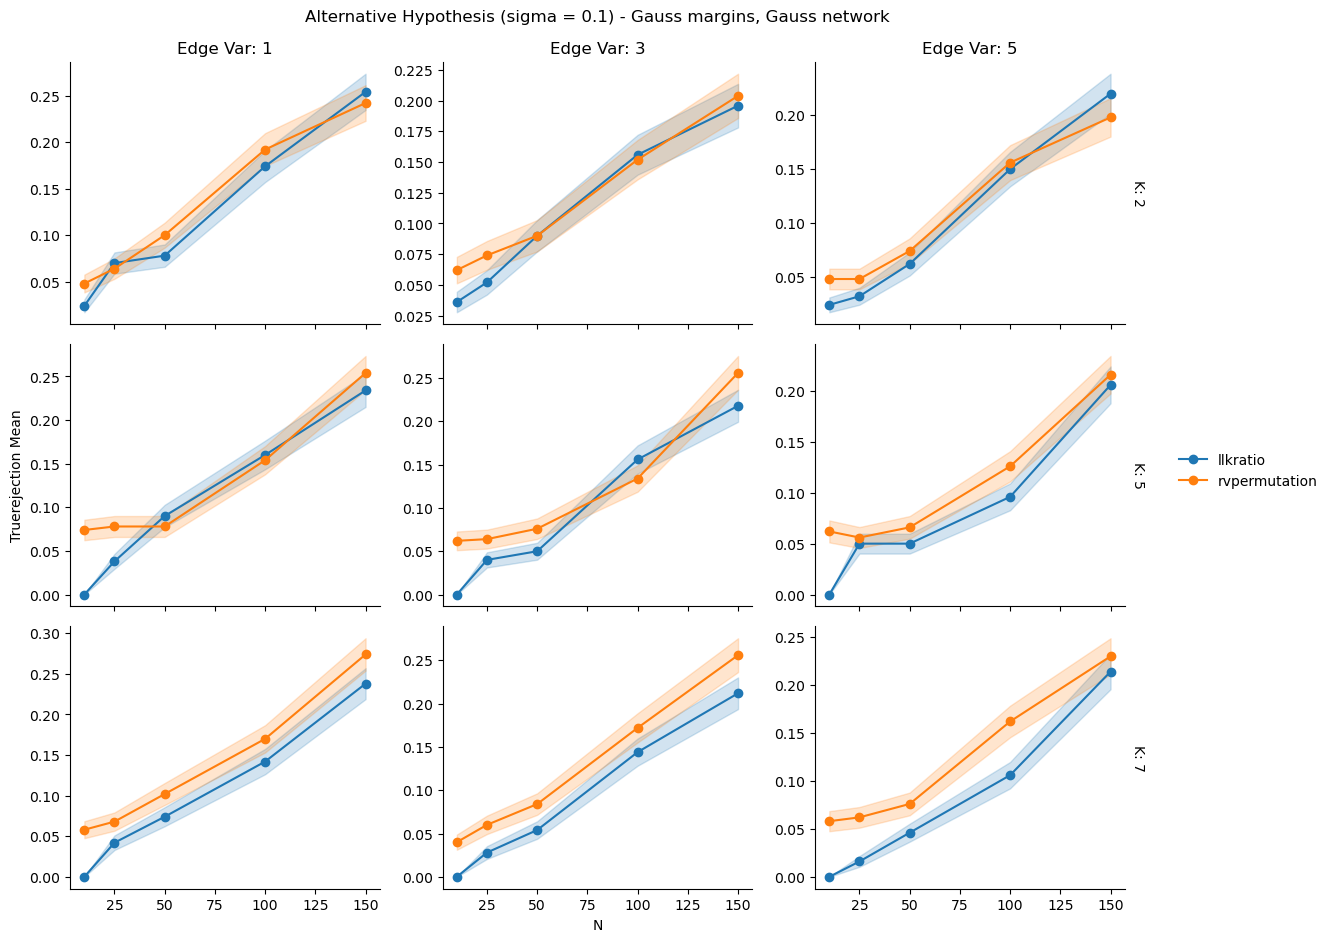

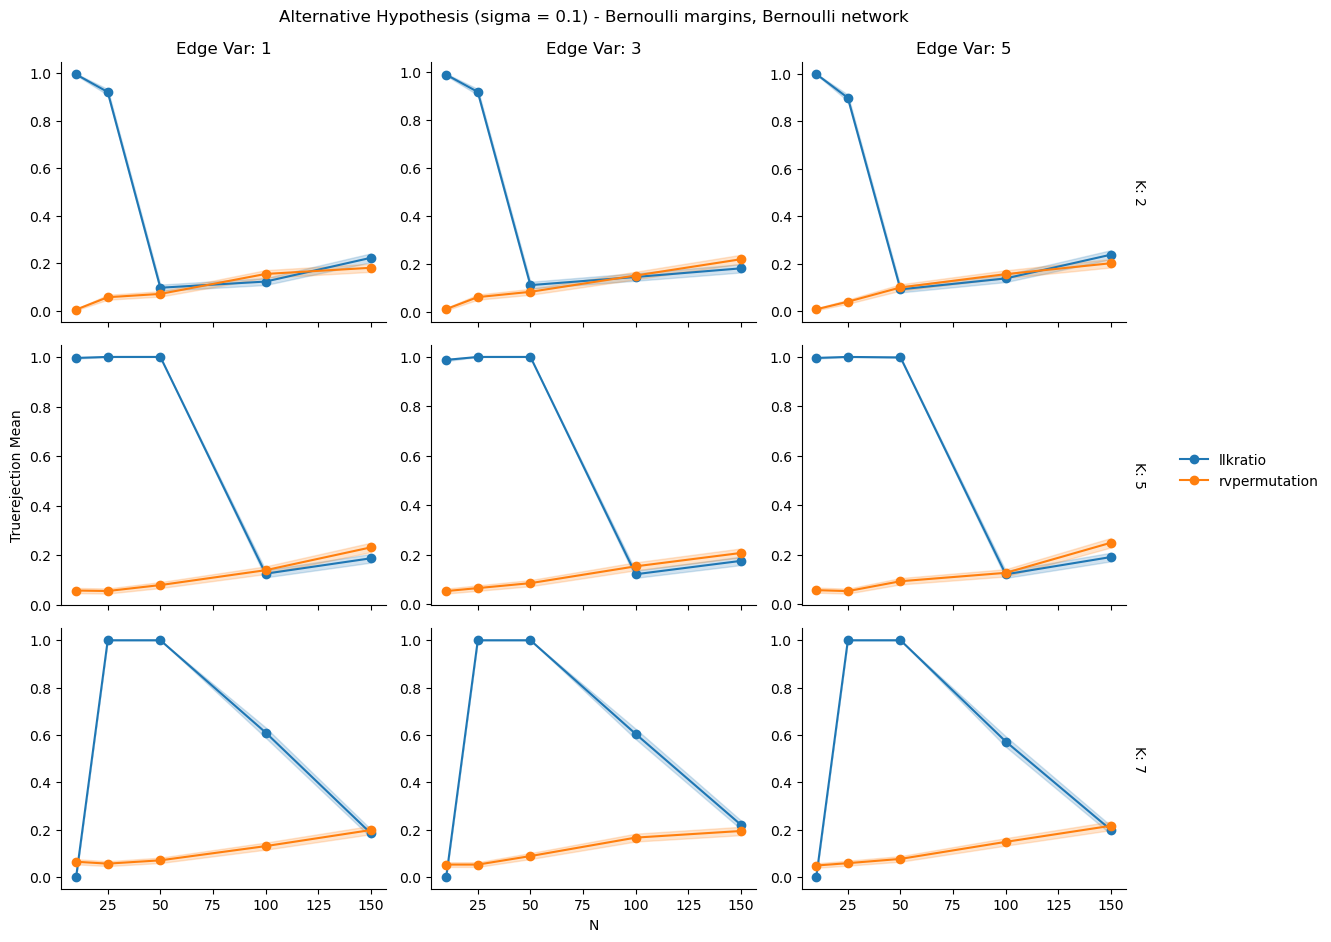

In [18]:
# sigma 0.1
plot_grid(
        grouped_stats=agg_alt_01_gaussian_gaus_margins_gaus_mle,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='TrueRejection_mean',
        factors=['method', 'edge_var', 'k'],
        height=3,
        se_bands='TrueRejection_sem',
        share_x=True,
        share_y=False,
        title='Alternative Hypothesis (sigma = 0.1) - Gauss margins, Gauss network'
    )

plot_grid(
        grouped_stats=agg_alt_01_bernoulli_gaus_margins_logistic_mle,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='TrueRejection_mean',
        factors=['method', 'edge_var', 'k'],
        height=3,
        se_bands='TrueRejection_sem',
        share_x=True,
        share_y=False,
        title='Alternative Hypothesis (sigma = 0.1) - Bernoulli margins, Bernoulli network'
    )

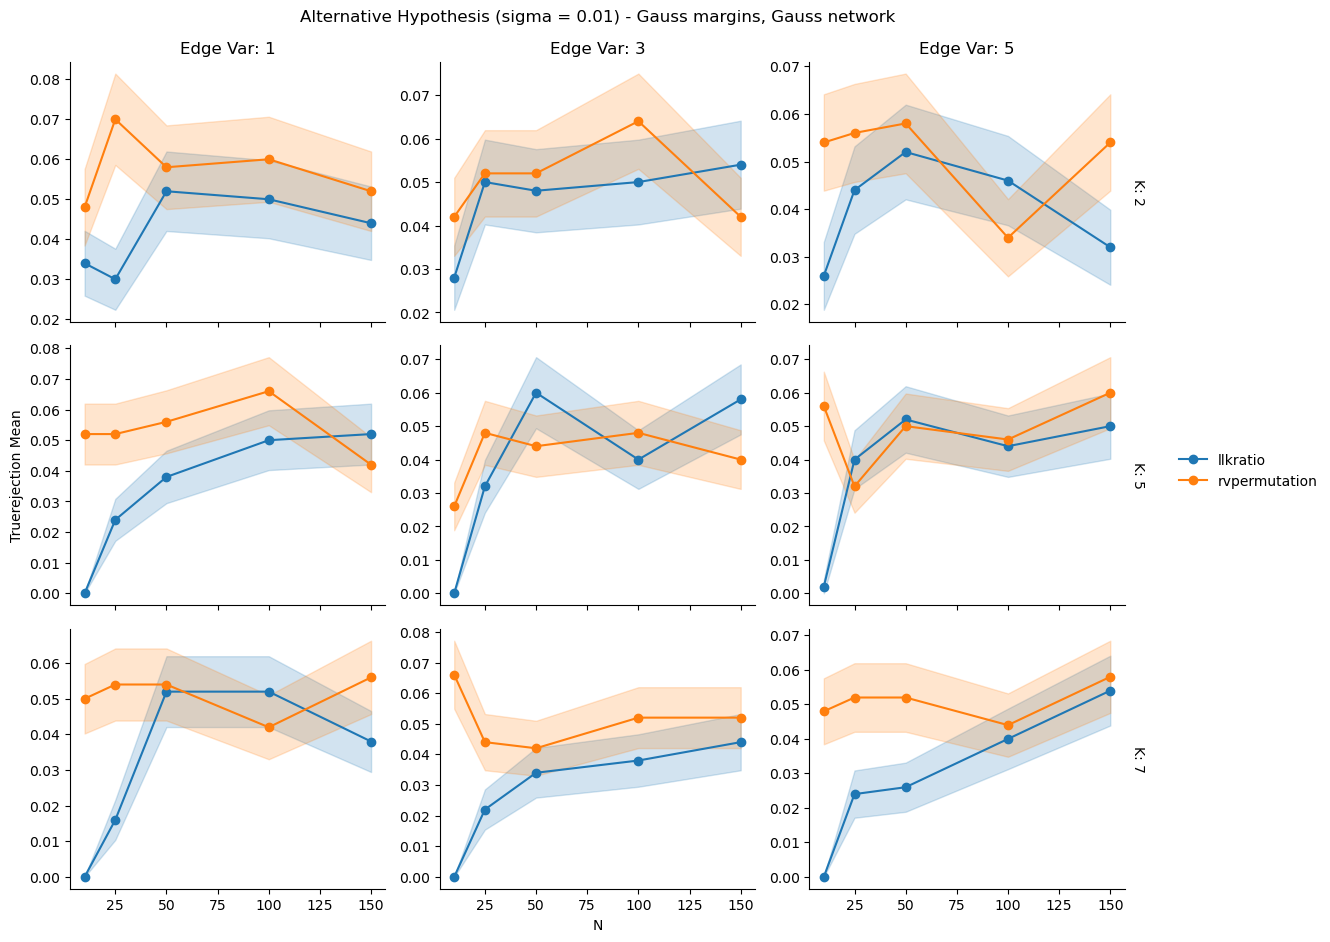

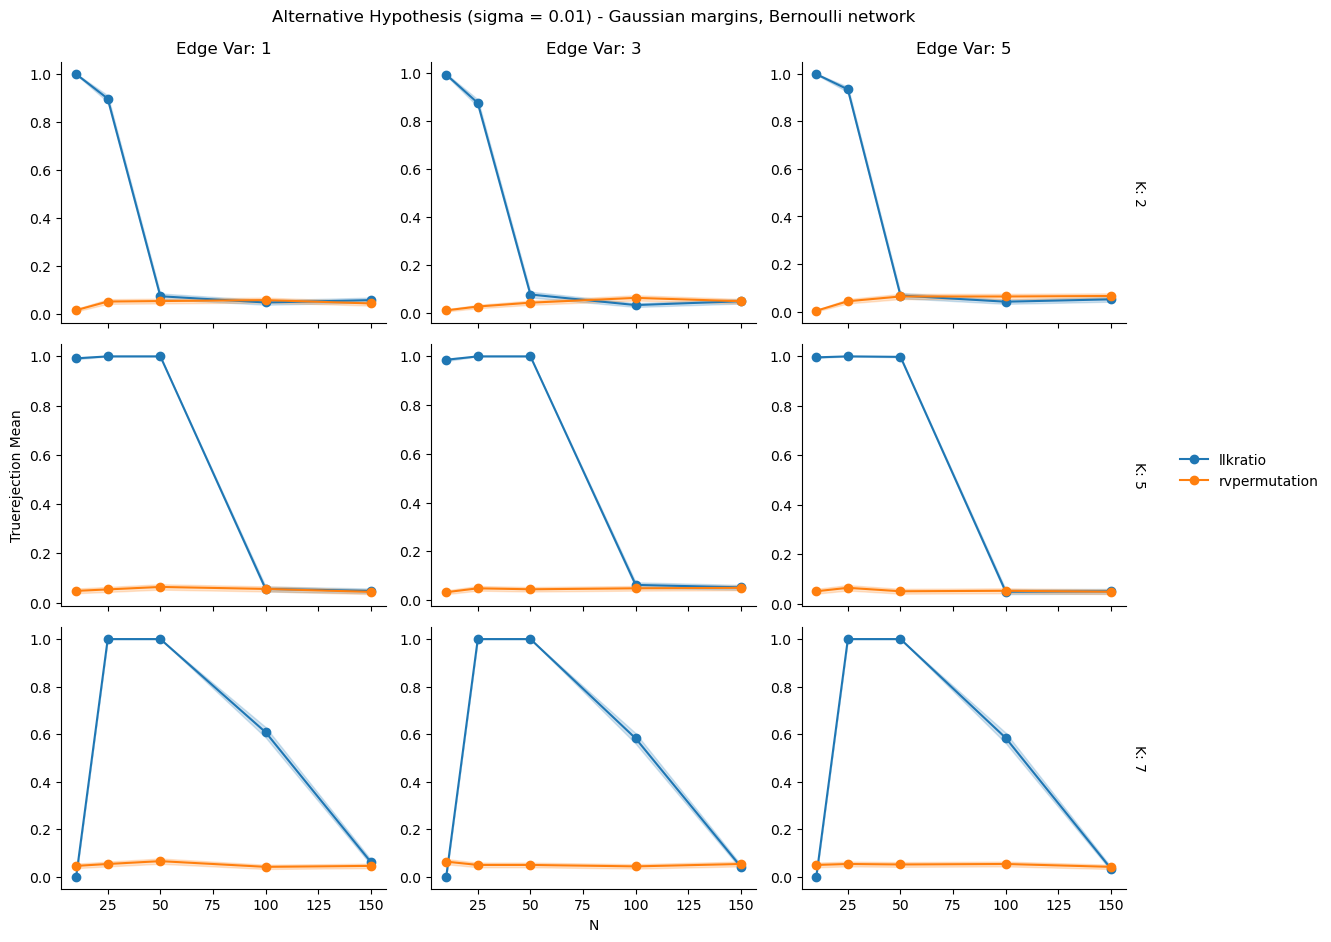

In [28]:
# sigmna 0.01
plot_grid(
        grouped_stats=agg_alt_001_gaussian_gaus_margins_gaus_mle,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='TrueRejection_mean',
        factors=['method', 'edge_var', 'k'],
        height=3,
        se_bands='TrueRejection_sem',
        share_x=True,
        share_y=False,
        title='Alternative Hypothesis (sigma = 0.01) - Gauss margins, Gauss network'
    )

plot_grid(
        grouped_stats=agg_alt_001_bernoulli_gaus_margins_logistic_mle,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='TrueRejection_mean',
        factors=['method', 'edge_var', 'k'],
        height=3,
        se_bands='TrueRejection_sem',
        share_x=True,
        share_y=False,
        title='Alternative Hypothesis (sigma = 0.01) - Gaussian margins, Bernoulli network'
    )

## Alternative beta margins

In [20]:
# # sigma 0.5
# plot_grid(
#         grouped_stats=agg_alt_05_gaussian_beta_margins_gaus_mle,
#         plotting_function=plot_with_bands,
#         x_axis='n',
#         y_axis='TrueRejection_mean',
#         factors=['method', 'edge_var', 'k'],
#         height=3,
#         se_bands='TrueRejection_sem',
#         share_x=True,
#         share_y=False,
#         title='Alternative Hypothesis (sigma = 0.5) - Beta margins, Gauss network'
#     )

# plot_grid(
#         grouped_stats=agg_alt_05_bernoulli_beta_margins_logistic_mle,
#         plotting_function=plot_with_bands,
#         x_axis='n',
#         y_axis='TrueRejection_mean',
#         factors=['method', 'edge_var', 'k'],
#         height=3,
#         se_bands='TrueRejection_sem',
#         share_x=True,
#         share_y=False,
#         title='Alternative Hypothesis (sigma = 0.5) - Beta margins, Bernoulli network'
#     )

In [21]:
# # sigma 0.1
# plot_grid(
#         grouped_stats=agg_alt_01_gaussian_beta_margins_gaus_mle,
#         plotting_function=plot_with_bands,
#         x_axis='n',
#         y_axis='TrueRejection_mean',
#         factors=['method', 'edge_var', 'k'],
#         height=3,
#         se_bands='TrueRejection_sem',
#         share_x=True,
#         share_y=False,
#         title='Alternative Hypothesis (sigma = 0.1) - Beta margins, Gauss network'
#     )

# plot_grid(
#         grouped_stats=agg_alt_01_bernoulli_beta_margins_logistic_mle,
#         plotting_function=plot_with_bands,
#         x_axis='n',
#         y_axis='TrueRejection_mean',
#         factors=['method', 'edge_var', 'k'],
#         height=3,
#         se_bands='TrueRejection_sem',
#         share_x=True,
#         share_y=False,
#         title='Alternative Hypothesis (sigma = 0.1) - Bernoulli margins, Bernoulli network'
#     )

In [23]:
# # sigma 0.01
# plot_grid(
#         grouped_stats=agg_alt_001_gaussian_beta_margins_gaus_mle,
#         plotting_function=plot_with_bands,
#         x_axis='n',
#         y_axis='TrueRejection_mean',
#         factors=['method', 'edge_var', 'k'],
#         height=3,
#         se_bands='TrueRejection_sem',
#         share_x=True,
#         share_y=False,
#         title='Alternative Hypothesis (sigma = 0.01) - Gauss margins, Gauss network'
#     )

# plot_grid(
#         grouped_stats=agg_alt_001_bernoulli_beta_margins_logistic_mle,
#         plotting_function=plot_with_bands,
#         x_axis='n',
#         y_axis='TrueRejection_mean',
#         factors=['method', 'edge_var', 'k'],
#         height=3,
#         se_bands='TrueRejection_sem',
#         share_x=True,
#         share_y=False,
#         title='Alternative Hypothesis (sigma = 0.01) - Bernoulli margins, Bernoulli network'
#     )

# Study latent position recovery

In [24]:
agg_null_gaussian_gaus_margins_gaus_mle_norm_x = aggregate_results(results_null_gaussian_gaus_margins_gaus_mle, y_axis='RelativeFrobeniusNorm_x', x_axis='n', factors=['edge_var', 'k', 'method'])
agg_null_gaussian_gaus_margins_gaus_mle_norm_z = aggregate_results(results_null_gaussian_gaus_margins_gaus_mle, y_axis='RelativeFrobeniusNorm_z', x_axis='n', factors=['edge_var', 'k', 'method'])

# agg_null_gaussian_beta_margins_gaus_mle_norm_x = aggregate_results(results_null_gaussian_beta_margins_gaus_mle, y_axis='RelativeFrobeniusNorm_x', x_axis='n', factors=['edge_var', 'k', 'method'])
# agg_null_gaussian_beta_margins_gaus_mle_norm_z = aggregate_results(results_null_gaussian_beta_margins_gaus_mle, y_axis='RelativeFrobeniusNorm_z', x_axis='n', factors=['edge_var', 'k', 'method'])

agg_null_bernoulli_gaus_margins_logistic_mle_norm_x = aggregate_results(results_null_bernoulli_gaus_margins_logistic_mle, y_axis='RelativeFrobeniusNorm_x', x_axis='n', factors=['edge_var', 'k', 'method'])
agg_null_bernoulli_gaus_margins_logistic_mle_norm_z = aggregate_results(results_null_bernoulli_gaus_margins_logistic_mle, y_axis='RelativeFrobeniusNorm_z', x_axis='n', factors=['edge_var', 'k', 'method'])

# agg_null_bernoulli_beta_margins_logistic_mle_norm_x = aggregate_results(results_null_bernoulli_beta_margins_logistic_mle, y_axis='RelativeFrobeniusNorm_x', x_axis='n', factors=['edge_var', 'k', 'method'])
# agg_null_bernoulli_beta_margins_logistic_mle_norm_z = aggregate_results(results_null_bernoulli_beta_margins_logistic_mle, y_axis='RelativeFrobeniusNorm_z', x_axis='n', factors=['edge_var', 'k', 'method'])

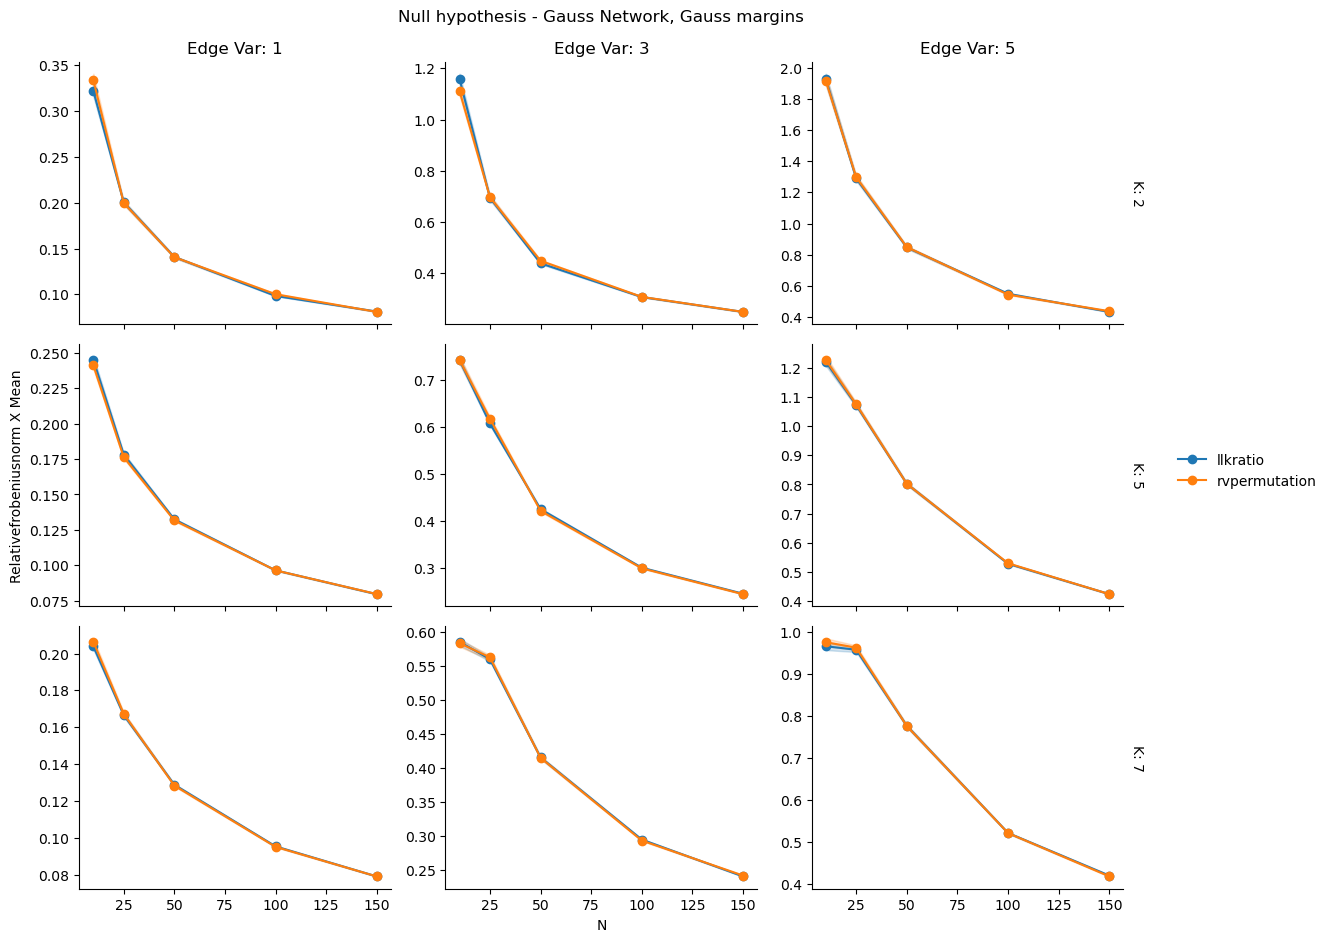

In [25]:
plot_grid(
        grouped_stats=agg_null_gaussian_gaus_margins_gaus_mle_norm_x,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='RelativeFrobeniusNorm_x_mean',
        factors=['method', 'edge_var', 'k'],
        height=3,
        se_bands='RelativeFrobeniusNorm_x_sem',
        share_x=True,
        share_y=False,
        title='Null hypothesis - Gauss Network, Gauss margins'
    )

In [26]:
# plot_grid(
#         grouped_stats=agg_null_gaussian_beta_margins_gaus_mle_norm_x,
#         plotting_function=plot_with_bands,
#         x_axis='n',
#         y_axis='RelativeFrobeniusNorm_x_mean',
#         factors=['method', 'edge_var', 'k'],
#         height=3,
#         se_bands='RelativeFrobeniusNorm_x_sem',
#         share_x=True,
#         share_y=False,
#         title='Null hypothesis - Gauss Network, Beta margins'
#     )

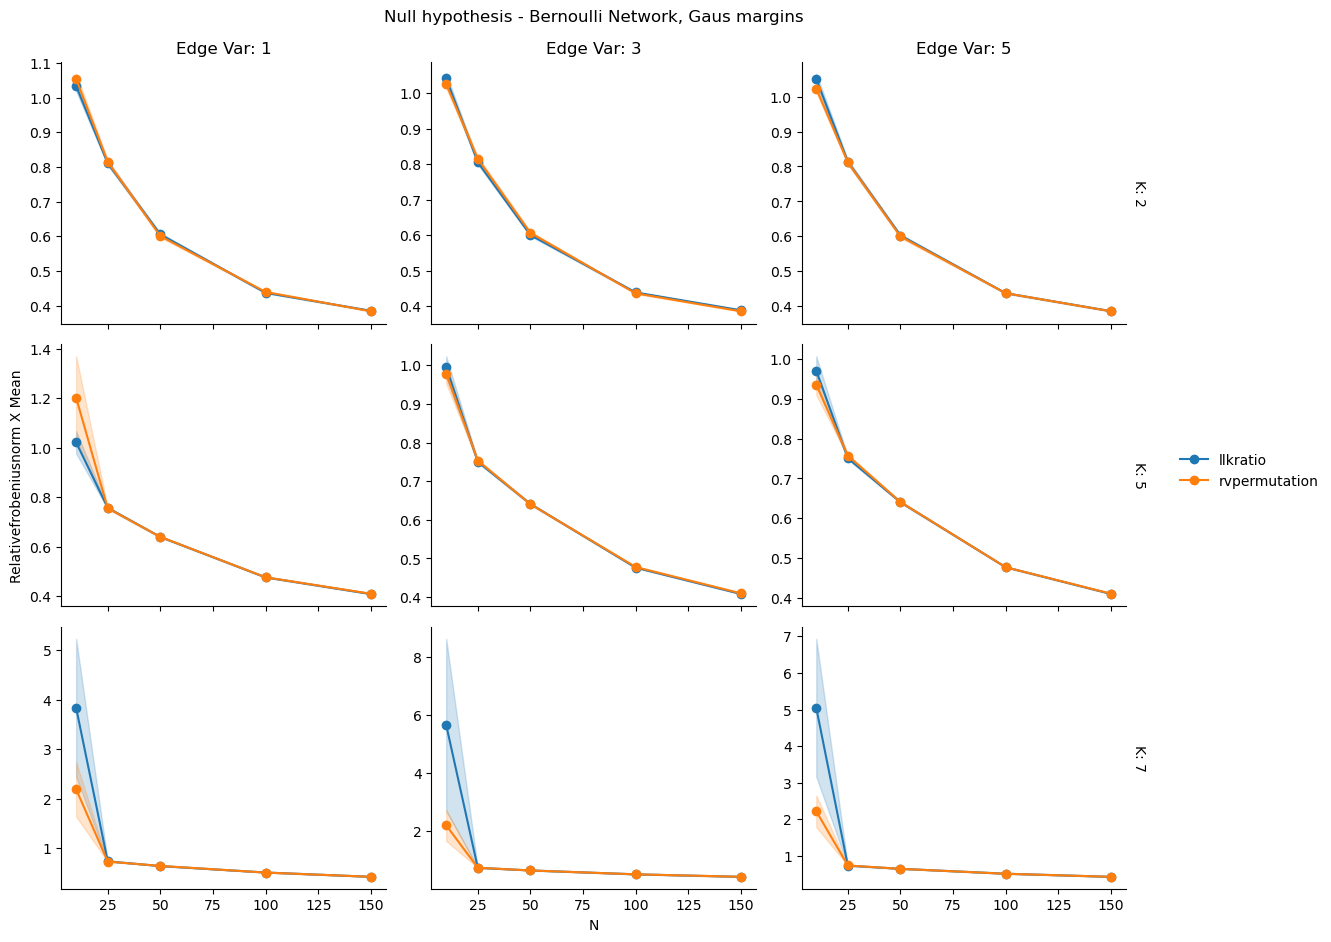

In [27]:
plot_grid(
        grouped_stats=agg_null_bernoulli_gaus_margins_logistic_mle_norm_x,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='RelativeFrobeniusNorm_x_mean',
        factors=['method', 'edge_var', 'k'],
        height=3,
        se_bands='RelativeFrobeniusNorm_x_sem',
        share_x=True,
        share_y=False,
        title='Null hypothesis - Bernoulli Network, Gaus margins'
    )

# BUnch of code

In [ ]:
plot_grid(
        grouped_stats=agg_alt_001_gaussian,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='TrueRejection_mean',
        factors=['edge_var', 'method', 'k'],
        height=3,
        se_bands='TrueRejection_sem',
        share_x=True,
        share_y=False,
        title='Alternative Hypothesis (sigma = 0.01)'
    )

NameError: name 'agg_alt_001_gaussian' is not defined

In [ ]:
plot_grid(
        grouped_stats=agg_llk_ratio_alternative,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='TrueRejection_mean',
        factors=['edge_var', 'k'],
        height=3,
        se_bands='TrueRejection_sem',
        share_x=True,
        share_y=False,
        title='LLK Ratio - Alternative Hypothesis (sigma-0.5)'
    )

plot_grid(
        grouped_stats=agg_rv_alternative,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='TrueRejection_mean',
        factors=['edge_var', 'k'],
        height=3,
        se_bands='TrueRejection_sem',
        share_x=True,
        share_y=False,
        title='RV permutation - Alternative Hypothesis (sigma-0.5)'
    )

NameError: name 'agg_llk_ratio_alternative' is not defined